**1. SUMMARY**

This project analyzes Netflix’s global catalog to uncover content distribution patterns, identify temporal and geographic trends, and build a KNN-based classification model to predict whether a title is a Movie or TV Show.

**2.BUSINESS UNDERSTANDING**

Business questions:

- What type of content dominates the platform?
- Which countries contribute most to catalog growth?
- How has content evolved over time?

**3. DATA LOADING AND INITIAL INSPECTION**

In [ ]:
# =========================
# 3.1 Environment Setup
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

# Visual Configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# =========================
# 3.2 Google Drive Connection
# =========================
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/netflix_project/data/raw/netflix_titles.csv"

Mounted at /content/drive


In [ ]:
# =========================
# 3.3 Dataset Loading
# =========================
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
# =================================
# 3.4 Initial Structural Inspection
# =================================

# Count number of rows and columns
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Name of columns
df.columns.tolist()

# First look to table
df.head()

# Data types
df.info()

# Statistical summary, include (count, unique, top, freq, mean, std, min, 25%,50%,75%, and max)
df.describe(include="all")

# Duplicate check
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

Rows: 7787
Columns: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB
Duplicate rows: 0


3.5 Initial Findings

The dataset contains Netflix catalog, including title type, release year, country, genre, duration and audience rating.

- Mixed data types across temporal and categorical columns.
- Missing values in fields such as director and cast.
- Multi-value categorical fields (country and listed_in).
- Mixed duration units between movies and TV shows.
- Likely need for feature extraction form date_added and duration.
- Several fields such as director, cast, country and listed_in, contain multiple comma-separated values within a single cell.

**4. DATA QUALITY ASSESMENT**

In this section, the question to address is: How reliable, consistent, and useful is the dataset before transformation?

In [ ]:
# =============================================
# 4.1 Completeness Assessment (Missing Values)
# =============================================
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

quality_missing = (
    pd.DataFrame({
        "missing_values": missing_values,
        "missing_percentage": missing_percentage
    })
    .sort_values("missing_percentage", ascending=False)
)

quality_missing

,missing_values,missing_percentage
director,2389,30.679337
cast,718,9.220496
country,507,6.510851
date_added,10,0.128419
rating,7,0.089893
title,0,0.000000
show_id,0,0.000000
type,0,0.000000
release_year,0,0.000000
duration,0,0.000000


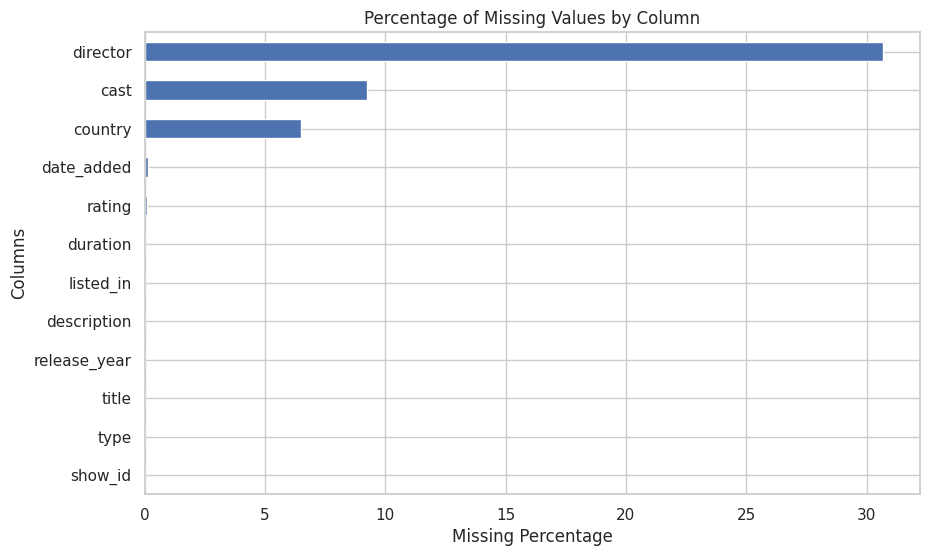

In [ ]:
# Bar chart of percentage of missing values by column

plt.figure(figsize=(10,6))
quality_missing["missing_percentage"].sort_values().plot(kind="barh")
plt.title("Percentage of Missing Values by Column")
plt.xlabel("Missing Percentage")
plt.ylabel("Columns")
plt.show()

In [ ]:
# ====================================================
# 4.2 Uniqueness Assessment (Duplicate and cardinality)
# ====================================================

duplicate_rows = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_rows}")

cardinality = df.nunique().sort_values(ascending=False)
cardinality

Duplicate rows found: 0


,0
show_id,7787
title,7787
description,7769
cast,6831
director,4049
date_added,1565
country,681
listed_in,492
duration,216
release_year,73


In [ ]:
# =================================
# 4.3 Validity and Data type issues
# =================================

# date_added field
invalid_dates = df["date_added"].isna().sum()
print(f"Missing or invalid date_added: {invalid_dates}")

# duration field
df["duration"].dropna().sample(10)

Missing or invalid date_added: 10


,duration
7571,3 Seasons
550,64 min
2734,104 min
4393,97 min
7167,59 min
6837,90 min
4025,84 min
3061,1 Season
3500,92 min
2885,106 min


In [ ]:
# release_year field
df["release_year"].describe()

,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


In [ ]:
# ===================================
# 4.4 Atomicity and Multi-value fields
# ===================================

multi_value_columns = ["director", "cast", "country", "listed_in"]

for col in multi_value_columns:
    multi_count = df[col].fillna("").str.contains(",").sum()
    print(f"{col}: {multi_count} multi-value rows")

director: 553 multi-value rows
cast: 6241 multi-value rows
country: 1153 multi-value rows
listed_in: 5986 multi-value rows


**ATOMICITY FINDINGS**

Several fields violate atomicity principles by storing multiple entities in a single cell.

This impacts:
- frequency analysis
- geographic distribution
- genre (liested_in) segmentation
- feature engineering
- dashboard normalization

**5. DATA CLEANING AND TRANSFORMATION**

In this section, the question to address is: How can I transform raw metadata into a consistent, interpretable and suitable for analytics?

In [ ]:
# =========================
# 5.1 Missing Value Treatment
# =========================

df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Not Available")
df["country"] = df["country"].fillna("Unknown")

df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

Instead of leaving missing data blank, we filled those spots with specific labels (like "Unknown" or "Not Available"). This keeps the records complete, making it easier to analyze those categories later.

In [ ]:
# =============================
# 5.1.1 Global Text Sanitization
# =============================

# Drop line break to avoid errors
df = df.replace({r"[\r\n]+": " "}, regex=True)
df = df.replace({r"\s{2,}": " "}, regex=True)

In [ ]:
# ==============================================
# 5.2 Date Standardization and Temporal Filtering
# ==============================================
rows_before = len(df)

# Parse datetime
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

# Remove invalid or missing parsed dates
df = df.dropna(subset=["date_added"]).copy()

rows_removed = rows_before - len(df)
print(f"Rows removed due to invalid or missing dates: {rows_removed}")

# Create temporal analytical features
df["year_added"] = df["date_added"].dt.year.astype(int)
df["month_added"] = df["date_added"].dt.month.astype(int)

# Validation
print(df[["date_added", "year_added", "month_added"]].isnull().sum())

Rows removed due to invalid or missing dates: 98
date_added     0
year_added     0
month_added    0
dtype: int64


In [ ]:
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description',
 'year_added',
 'month_added']

In [ ]:
# =========================
# 5.3 Duration Parsing
# =========================
df["duration_num"] = df["duration"].str.extract(r"(\d+)").astype(float)
df["duration_unit"] = df["duration"].str.extract(r"([A-Za-z]+)")

In [ ]:
# ==================================
# 5.4 Multi-value field normalization
# ==================================
# Create reusable derived features

# director count
df["director_count"] = df["director"].apply(lambda x: len(str(x).split(",")))
print(df["director_count"])

# cast count
df["cast_count"] = df["cast"].apply(lambda x: len(str(x).split(",")))
print(df["cast_count"])

#country count
df["country_count"] = df["country"].apply(lambda x: len(str(x).split(",")))
print(df["country_count"])

# main genre
df["main_genre"] = df["listed_in"].str.split(", ").str[0]
print(df["main_genre"])

df.head()

0       1
1       1
2       1
3       1
4       1
       ..
7782    1
7783    1
7784    1
7785    1
7786    1
Name: director_count, Length: 7689, dtype: int64
0       11
1        6
2        9
3        9
4       12
        ..
7782     7
7783     8
7784     1
7785     2
7786     1
Name: cast_count, Length: 7689, dtype: int64
0       1
1       1
2       1
3       1
4       1
       ..
7782    5
7783    1
7784    1
7785    1
7786    3
Name: country_count, Length: 7689, dtype: int64
0       International TV Shows
1                       Dramas
2                Horror Movies
3           Action & Adventure
4                       Dramas
                 ...          
7782                    Dramas
7783                    Dramas
7784             Documentaries
7785    International TV Shows
7786             Documentaries
Name: main_genre, Length: 7689, dtype: object


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_num,duration_unit,director_count,cast_count,country_count,main_genre
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,4.0,Seasons,1,11,1,International TV Shows
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,93.0,min,1,6,1,Dramas
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12,78.0,min,1,9,1,Horror Movies
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11,80.0,min,1,9,1,Action & Adventure
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1,123.0,min,1,12,1,Dramas


In [ ]:
# =========================
# 5.5 Duplicate Handling
# =========================

# 1. Count how many duplicate rows exist
duplication = df.duplicated().sum()
print(f"Total number of duplicate rows to be deleted: {duplication}")

# 2. Delete duplicates
df = df.drop_duplicates()

Total number of duplicate rows to be deleted: 0


In [ ]:
# ==============================
# 5.6 Derived analytical features
# ==============================

# content age
current_year = pd.Timestamp.now().year
df["content_age"] = current_year - df["release_year"]

# is multi-country
df["is_multicountry"] = (df["country_count"] > 1).astype(int)

# is long movie
df["is_long_content"] = (df["duration_num"] > 120).astype(int)

In [ ]:
# ==============================
# 5.7 Final validation snapshot
# ==============================

df.info()
df.head()
df.isnull().sum().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 7689 entries, 0 to 7786
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          7689 non-null   object        
 1   type             7689 non-null   object        
 2   title            7689 non-null   object        
 3   director         7689 non-null   object        
 4   cast             7689 non-null   object        
 5   country          7689 non-null   object        
 6   date_added       7689 non-null   datetime64[ns]
 7   release_year     7689 non-null   int64         
 8   rating           7689 non-null   object        
 9   duration         7689 non-null   object        
 10  listed_in        7689 non-null   object        
 11  description      7689 non-null   object        
 12  year_added       7689 non-null   int64         
 13  month_added      7689 non-null   int64         
 14  duration_num     7689 non-null   float64     

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [ ]:
# Export the clean version for EDA, ML AND BI

df.to_csv(
    "/content/drive/MyDrive/netflix_project/data/processed/netflix_clean.csv",
    index=False
)

In [ ]:
# This features is only for ML

ml_features = [
    "release_year", "year_added", "duration_num",
    "director_count", "cast_count",
    "country_count", "content_age",
    "is_multicountry", "is_long_content",
    "main_genre", "rating", "type"
]

feature_store = df[ml_features].copy()

**6. EXPLORATORY DATA ANALYSIS (EDA)**

In this section, the question to address is: What structural and strategic patterns can be found in the Netflix catalog?

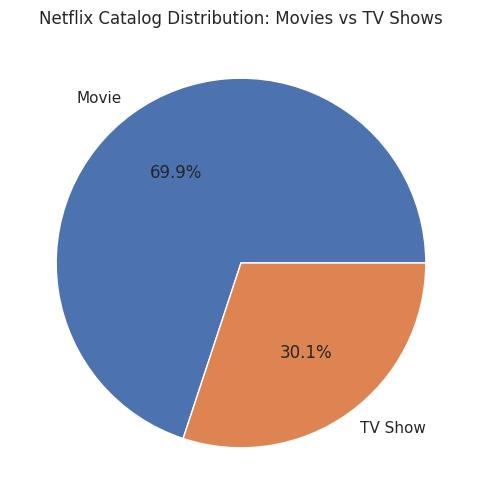

In [ ]:
# =========================
# 6.1 Content Distribution
# =========================

# What type of content dominates the platform?

content_dist = df["type"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(content_dist, labels=content_dist.index, autopct="%1.1f%%")
plt.title("Netflix Catalog Distribution: Movies vs TV Shows")
plt.show()

**INTERPRETATION**

The catalog is heavily movie-centric, suggesting Netflix’s historical emphasis on scalable film acquisitions over episodic content.

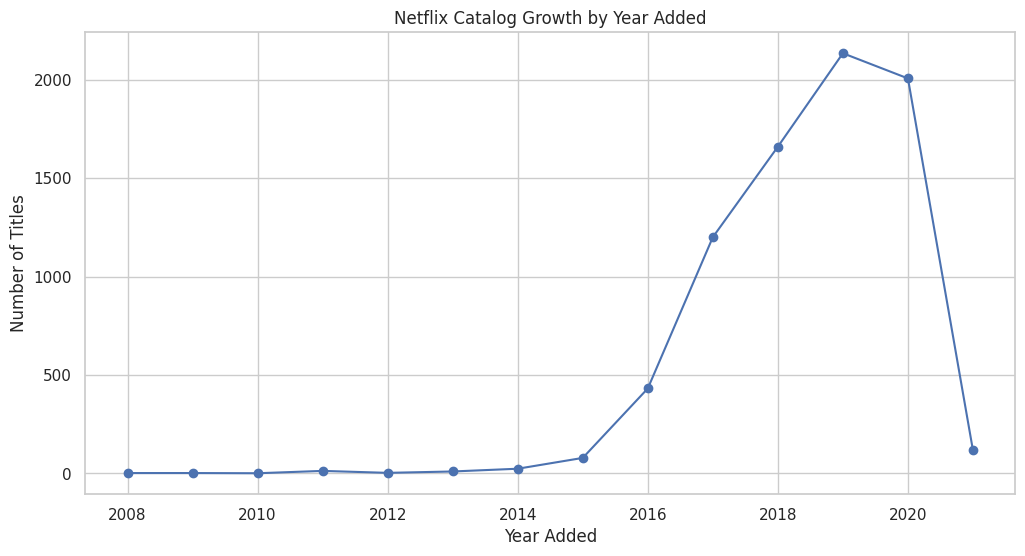

In [ ]:
# =========================
# 6.2 Temporal Evolution
# =========================

# How has the catalog envolved over time?

df_time = df.dropna(subset=["year_added"])

titles_per_year = df_time["year_added"].value_counts().sort_index()

plt.figure(figsize=(12,6))
titles_per_year.plot(kind="line", marker="o")
plt.title("Netflix Catalog Growth by Year Added")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()

**INTERPRETATION**

Netflix's catalog grew the fastest after 2016. This was likely because they started pushing to reach more countries and spending a lot more money making their own shows and movies.

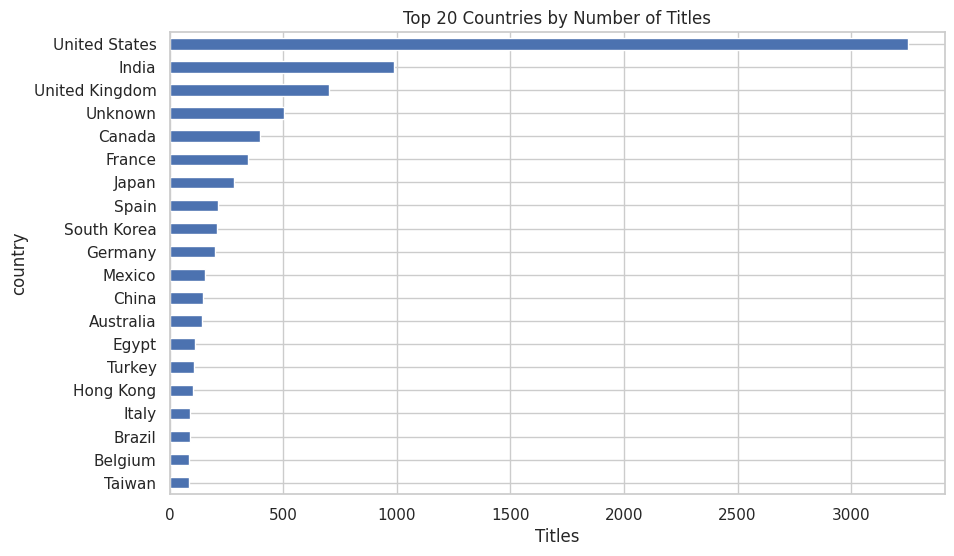

In [ ]:
# =========================
# 6.3 Geographic Expansion
# =========================

# Which countries drive catalog growth?

country_df = df.assign(
    country=df["country"].str.split(", ")
).explode("country")

top_countries = country_df["country"].value_counts().head(20)

plt.figure(figsize=(10,6))
top_countries.sort_values().plot(kind="barh")
plt.title("Top 20 Countries by Number of Titles")
plt.xlabel("Titles")
plt.show()

**INTERPRETATION**

Netflix added the most new titles in North America and India. This shows they are focusing on different types of content to satisfy viewers in their biggest and fastest-growing markets.

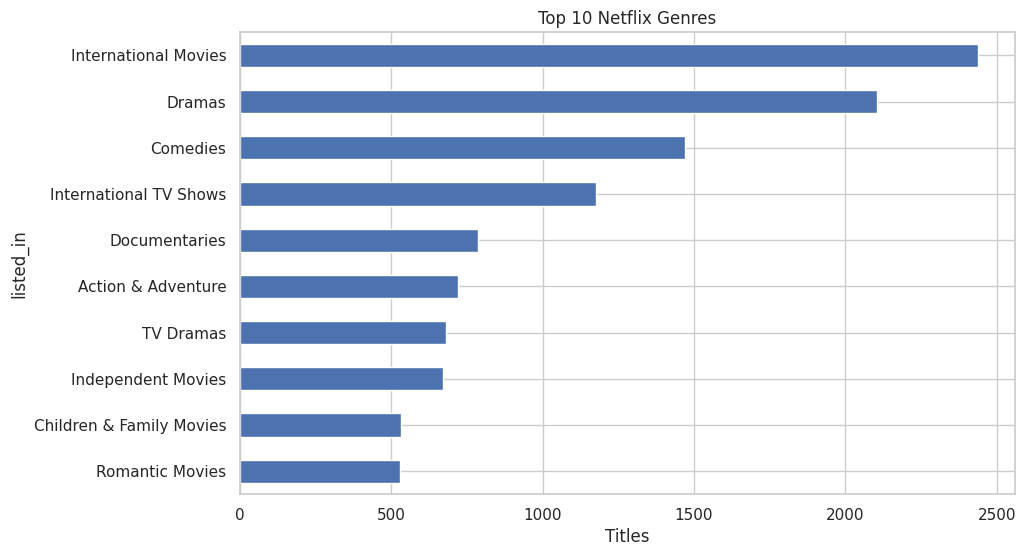

In [ ]:
# =========================
# 6.4 Genres Dominate
# =========================

# Which genres dominate the catalog?

genre_df = df.assign(
    listed_in=df["listed_in"].str.split(", ")
).explode("listed_in")

top_genres = genre_df["listed_in"].value_counts().head(10)

plt.figure(figsize=(10,6))
top_genres.sort_values().plot(kind="barh")
plt.title("Top 10 Netflix Genres")
plt.xlabel("Titles")
plt.show()

**INTERPRETATION**

Netflix is dominated by international movies and dramas. This is because they focus on making and buying content that appeals to people in many different countries and cultures.

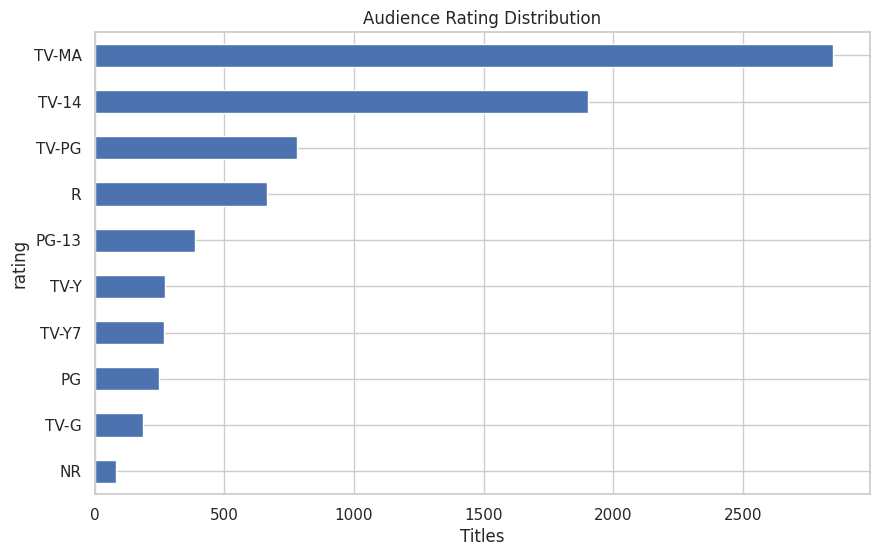

In [ ]:
# =========================
# 6.5 Audience Segmentation
# =========================

# Is Netflix more adult-oriented or family-oriented?

top_ratings = df["rating"].value_counts().head(10)

plt.figure(figsize=(10,6))
top_ratings.sort_values().plot(kind="barh")
plt.title("Audience Rating Distribution")
plt.xlabel("Titles")
plt.show()

**INTERPRETATION**

The platform appears strongly oriented toward mature audiences, with TV-MA and TV-14 leading the catalog mix.

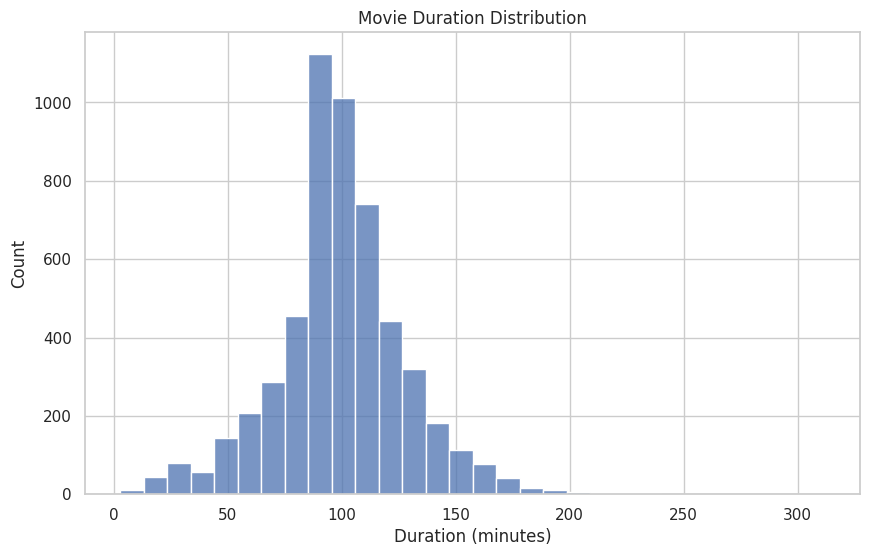

In [ ]:
# ====================
# 6.6 Duration (movies)
# ====================

# What is the structural duration profile of Netflix content?

movies = df[df["type"] == "Movie"]

plt.figure(figsize=(10,6))
sns.histplot(movies["duration_num"], bins=30)
plt.title("Movie Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.show()

**INTERPRETATION**

Most films adhere to standard running times, which align with conventional audience retention patterns.

In [ ]:
# CREATE A SUMMARY

eda_summary = pd.DataFrame({
    "Question": [
        "Content Mix",
        "Growth Trend",
        "Geographic Focus",
        "Genre Dominance",
        "Audience Segment"
    ],
    "Key Insight": [
        "Movies dominate the catalog",
        "Rapid expansion after 2016",
        "US and India lead content production",
        "International movies and dramas dominate",
        "Adult-focused catalog"
    ]
})

eda_summary

,Question,Key Insight
0,Content Mix,Movies dominate the catalog
1,Growth Trend,Rapid expansion after 2016
2,Geographic Focus,US and India lead content production
3,Genre Dominance,International movies and dramas dominate
4,Audience Segment,Adult-focused catalog


In [ ]:
# EXPORT EDA SUMMARY (NOT GRAPHS)

eda_summary.to_csv(
    "/content/drive/MyDrive/netflix_project/data/processed/eda_summary.csv",
    index=False
)

**In this section, I will store the exploded datasets so I can use them later in Power BI**

In [ ]:
# Storing country_df

country_export = country_df.rename(columns={
    "country": "country_name"
})

country_export.to_csv(
    "/content/drive/MyDrive/netflix_project/data/processed/country_exploded.csv",
    index=False
)
print("country_exploded.csv saved successfully.")

# Storing genre_df

genre_export = genre_df.rename(columns={
    "listed_in": "genre"
})

genre_export.to_csv(
    "/content/drive/MyDrive/netflix_project/data/processed/genre_exploded.csv",
    index=False
)

print("genre_exploded.csv saved successfully.")

# Storing country x genre

country_genre_df = df.assign(
    country=df["country"].str.split(", "),
    listed_in=df["listed_in"].str.split(", ")
).explode("country").explode("listed_in")

country_genre_df.to_csv(
    "/content/drive/MyDrive/netflix_project/data/processed/country_genre_exploded.csv",
    index=False
)

print("country_genre_exploded.csv saved successfully.")

country_genre_exploded.csv saved successfully.


7. **MODELING PREPARATION**

In [ ]:
# ======================
# 7.1 Target Definition
# ======================
target = "type"

print(df[target].value_counts())

type
Movie      5377
TV Show    2312
Name: count, dtype: int64


In [ ]:
# ======================
# 7.2 Features Selection
# ======================

features = [
    "release_year",
    "year_added",
    "month_added",
    "duration_num",
    "director_count",
    "cast_count",
    "country_count",
    "content_age",
    "is_multicountry",
    "is_long_content",
    "main_genre",
    "rating"
]

In [ ]:
# ======================
# 7.3 Features Encoding
# ======================

from sklearn.preprocessing import LabelEncoder

model_df = df[features + [target]].copy()

# Encode categoricals

categorical_cols = ["main_genre", "rating", "type"]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    encoders[col] = le

# Handling 98 nulls in data_added (year_added and month_added)

model_df["year_added"] = model_df["year_added"].fillna(model_df["year_added"].median())
model_df["month_added"] = model_df["month_added"].fillna(model_df["month_added"].median())

In [ ]:
# ============
# 7.4 Scaling
# ============

# This section is just for KNN and Logistic regresion, DT does't need it

X = model_df.drop(columns=[target])
y = model_df[target]

In [ ]:
# ===================
# 7.5 Train-Test Split
# ===================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# =======================
# 7.6 feature Store Export
# =======================

model_df.to_csv(
    "/content/drive/MyDrive/netflix_project/data/processed/feature_store.csv",
    index=False
)

**8. MODELING CREATION**

In [ ]:
# ========
# 8.1 KNN
# ========

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)
knn_pred = knn_pipeline.predict(X_test)

In [ ]:
# ========================
# 8.2 Logistic Regression
# ========================

from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

In [ ]:
# ==================
# 8.3 Decision Tree
# ==================

from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

In [ ]:
# ========================
# 8.4 Comparative Benchmark
# ========================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

benchmark = pd.DataFrame({
    "Model": ["KNN", "Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, tree_pred)
    ],
    "Precision": [
        precision_score(y_test, knn_pred),
        precision_score(y_test, lr_pred),
        precision_score(y_test, tree_pred)
    ],
    "Recall": [
        recall_score(y_test, knn_pred),
        recall_score(y_test, lr_pred),
        recall_score(y_test, tree_pred)
    ],
    "F1 Score": [
        f1_score(y_test, knn_pred),
        f1_score(y_test, lr_pred),
        f1_score(y_test, tree_pred)
    ]
})

benchmark

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.985696,0.976190,0.976190,0.976190
1,Logistic Regression,0.996749,0.991398,0.997835,0.994606
2,Decision Tree,0.997399,0.995671,0.995671,0.995671


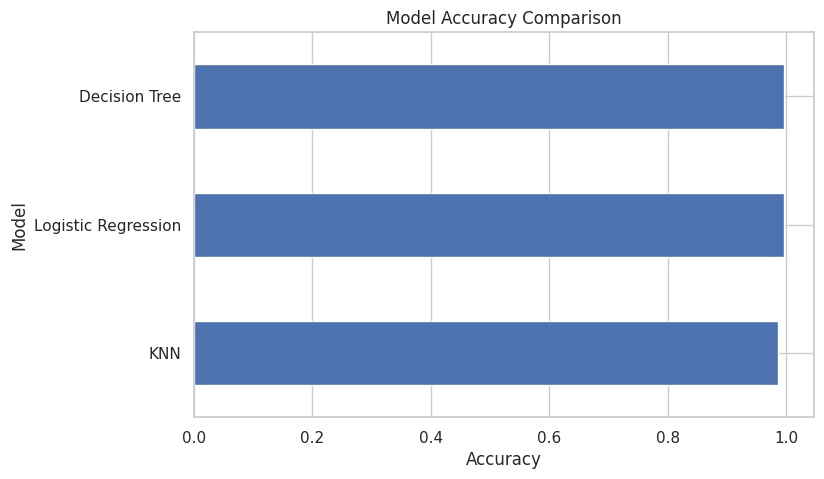

In [ ]:
# Benchmark Visual

benchmark.set_index("Model")["Accuracy"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.show()

In [ ]:
# Storing benchmark for Power BI

benchmark.to_csv(
    "/content/drive/MyDrive/netflix_project/data/processed/model_benchmark.csv",
    index=False
)

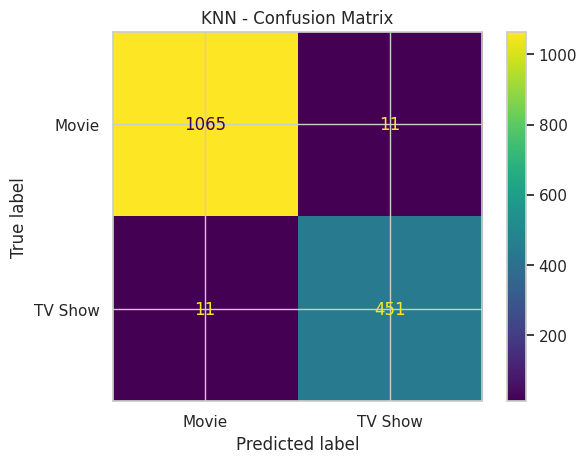

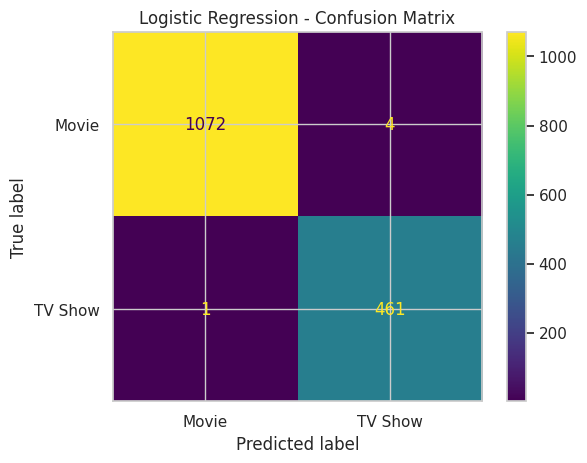

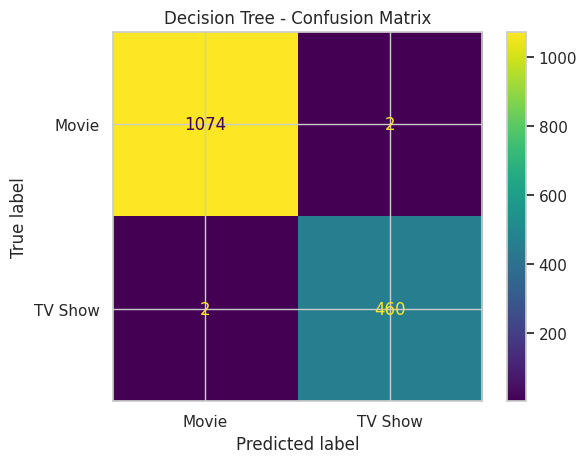

In [ ]:
# =======================
# 8.4.1 Confusion Matrix
# =======================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create Confusion Matrix for each model in a loop

predictions = {
    "KNN": knn_pred,
    "Logistic Regression": lr_pred,
    "Decision Tree": tree_pred
}

for model_name, pred in predictions.items():
    cm = confusion_matrix(y_test, pred)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=encoders["type"].classes_
    ).plot()

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

In [ ]:
# Table for each model

for model_name, pred in predictions.items():
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    print(f"\n{model_name}")
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")


KNN
TN: 1065, FP: 11, FN: 11, TP: 451

Logistic Regression
TN: 1072, FP: 4, FN: 1, TP: 461

Decision Tree
TN: 1074, FP: 2, FN: 2, TP: 460


**9. Model Explainability and Error Analysis**

In this section, the question to address is: Why does the model make decisions, and in what situations does it make mistakes?

In [ ]:
# =========================
# 9.1 Best Model Selection
# =========================

best_model_name = benchmark.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]["Model"]

print(f"Best model selected: {best_model_name}")

Best model selected: Decision Tree


In [ ]:
# =========================
# 9.2 Feature Importance
# =========================

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": tree_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(10)

,feature,importance
3,duration_num,0.995686
5,cast_count,0.001841
10,main_genre,0.000770
1,year_added,0.000644
11,rating,0.000515
7,content_age,0.000515
4,director_count,0.000028
0,release_year,0.000000
2,month_added,0.000000
6,country_count,0.000000


<Figure size 1000x600 with 0 Axes>

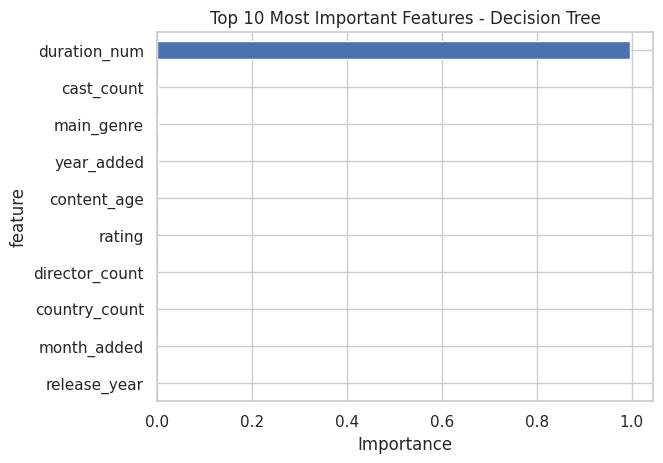

In [ ]:
# Visual of importance

plt.figure(figsize=(10,6))
feature_importance.head(10).sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False
)

plt.title("Top 10 Most Important Features - Decision Tree")
plt.xlabel("Importance")
plt.show()

**INTERPRETATION**

The best way to categorize the data is by **duration**. This makes sense because there is a clear difference between the length of a single movie and a TV show with many episodes.

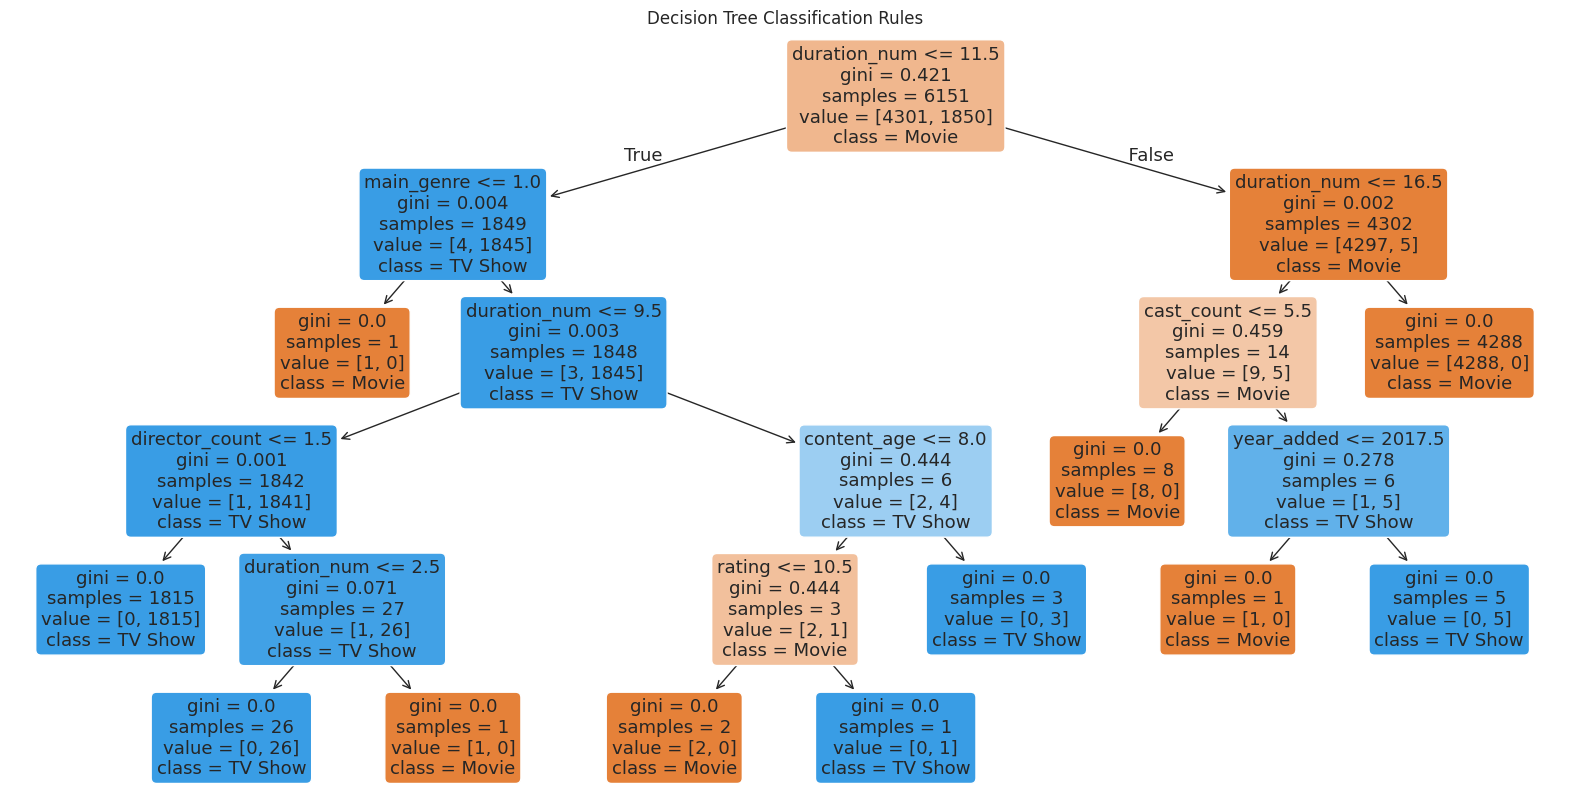

In [ ]:
# ==============================
# 9.3 Decision Tree Visualization
# ==============================

from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=encoders["type"].classes_,
    filled=True,
    rounded=True
)
plt.title("Decision Tree Classification Rules")
plt.show()

In [ ]:
# =========================
# 9.4 Error Slice Analysis
# =========================

error_df = X_test.copy()
error_df["actual"] = y_test
error_df["predicted"] = tree_pred
error_df["is_error"] = (error_df["actual"] != error_df["predicted"]).astype(int)

error_df["is_error"].value_counts()

,count
is_error,
0,1534
1,4


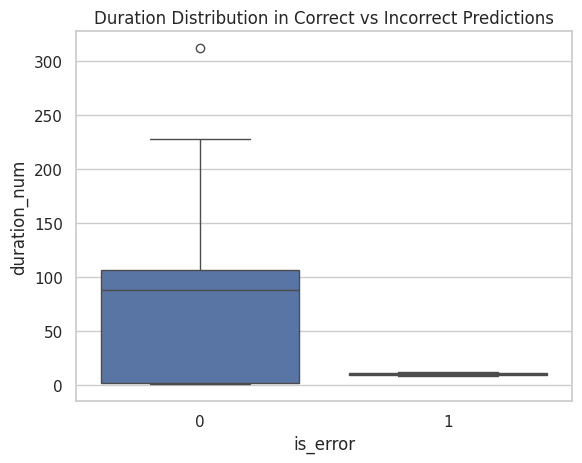

In [ ]:
# Error by duration

sns.boxplot(data=error_df, x="is_error", y="duration_num")
plt.title("Duration Distribution in Correct vs Incorrect Predictions")
plt.show()

In [ ]:
# ================================
# 9.5 Misclassification Diagnostics
# ================================

error_df["main_genre_decoded"] = encoders["main_genre"].inverse_transform(
    error_df["main_genre"].astype(int)
)

genre_errors = (
    error_df.groupby("main_genre_decoded")["is_error"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

genre_errors

,is_error
main_genre_decoded,
TV Comedies,0.041667
Children & Family Movies,0.019608
Crime TV Shows,0.013699
Anime Series,0.000000
British TV Shows,0.000000
Classic & Cult TV,0.000000
Anime Features,0.000000
Classic Movies,0.000000
Comedies,0.000000


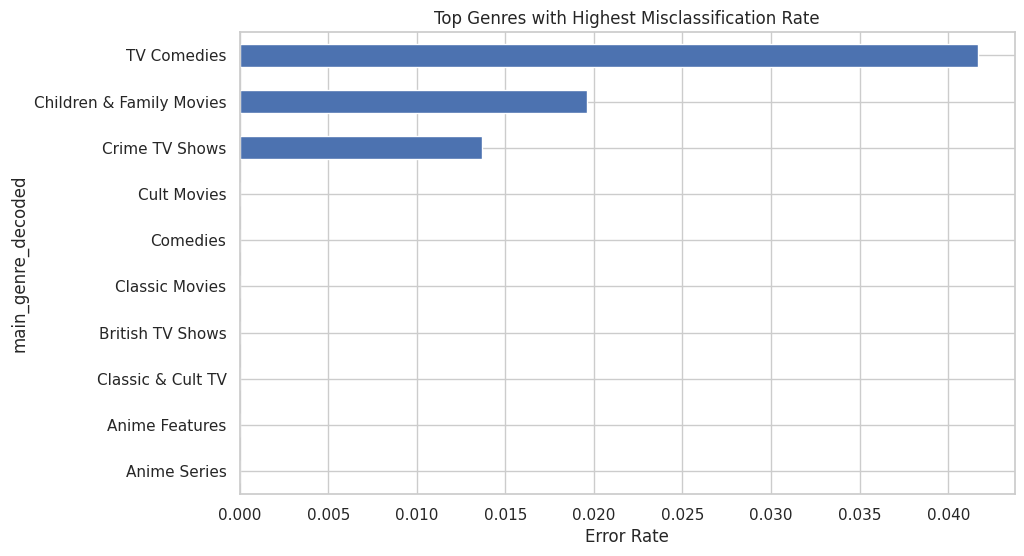

In [ ]:
# Genres visuals

plt.figure(figsize=(10,6))
genre_errors.sort_values().plot(kind="barh")
plt.title("Top Genres with Highest Misclassification Rate")
plt.xlabel("Error Rate")
plt.show()

In [ ]:
# EXPORT FEATURE IMPORTANCE AND ERROR FOR POWER BI

feature_importance.to_csv(
    "/content/drive/MyDrive/netflix_project/data/processed/feature_importance.csv",
    index=False
)

error_df.to_csv(
    "/content/drive/MyDrive/netflix_project/data/processed/error_diagnostics.csv",
    index=False
)